# Chapter 29: Dynamic Simulation and Process Control

This notebook demonstrates dynamic simulation and PID control using NeqSim.
We set up a three-phase separator with a PID level controller, introduce a step
change in feed rate, and observe the transient response of the liquid level and
controller output (valve position).

In [1]:
# Execute against the selected, compiled NeqSim source checkout.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jpype

if not os.environ.get("NEQSIM_PROJECT_ROOT"):
    raise RuntimeError("Set NEQSIM_PROJECT_ROOT to the NeqSim source checkout before running.")
PROJECT_ROOT = Path(os.environ["NEQSIM_PROJECT_ROOT"]).resolve()
if not (PROJECT_ROOT / "devtools" / "neqsim_dev_setup.py").exists():
    raise RuntimeError("NEQSIM_PROJECT_ROOT must contain devtools/neqsim_dev_setup.py.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False))
jneqsim = jpype.JPackage("neqsim")
NEQSIM_MODE = "devtools"
NOTEBOOK_PATH = Path(globals().get("__vsc_ipynb_file__", Path.cwd() / "ch20_dynamic_simulation.ipynb")).resolve()
BOOK_ROOT = NOTEBOOK_PATH.parents[3]
FIGURES_DIR = NOTEBOOK_PATH.parent.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(BOOK_ROOT / "devtools"))
from book_figure_tools import configure_figures, export_figure_summary
configure_figures()
print(f"NeqSim source: {PROJECT_ROOT}; Python: {sys.executable}")

# Named NeqSim class bindings used throughout the chapter.
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Pump = jneqsim.process.equipment.pump.Pump
Expander = jneqsim.process.equipment.expander.Expander
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem


All NeqSim classes imported OK
NeqSim source: C:\Users\solbraa\OneDrive - NTNU\Documents\ChatGPT\NeqSim; Python: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


## 29.1 Define the Feed Fluid

We create a typical well-stream fluid with gas, oil, and water components using
the SRK equation of state.

In [2]:
fluid = jneqsim.thermo.system.SystemSrkEos(273.15 + 60.0, 50.0)
fluid.addComponent("methane", 0.70)
fluid.addComponent("ethane", 0.05)
fluid.addComponent("propane", 0.03)
fluid.addComponent("n-heptane", 0.15)
fluid.addComponent("water", 0.07)
fluid.setMixingRule("classic")
fluid.setMultiPhaseCheck(True)

print("Feed fluid created with 5 components")

Feed fluid created with 5 components


## 29.2 Build the Process: Separator with Level Controller

We build a simple process with a feed stream, a three-phase separator, and a
liquid outlet valve controlled by a PID controller monitoring the separator liquid level.

In [3]:
# Create the feed stream
feed = jneqsim.process.equipment.stream.Stream("Feed", fluid)
feed.setFlowRate(5000.0, "kg/hr")
feed.setTemperature(60.0, "C")
feed.setPressure(50.0, "bara")

# Three-phase separator
separator = jneqsim.process.equipment.separator.ThreePhaseSeparator("HP Separator", feed)

# Liquid outlet valve
oil_valve = jneqsim.process.equipment.valve.ThrottlingValve("Oil Outlet Valve", separator.getOilOutStream())
oil_valve.setOutletPressure(30.0)

# Build and run the steady-state process
process = jneqsim.process.processmodel.ProcessSystem()
process.add(feed)
process.add(separator)
process.add(oil_valve)
process.run()

print(f"Separator gas out rate: {separator.getGasOutStream().getFlowRate('kg/hr'):.1f} kg/hr")
print(f"Separator oil out rate: {separator.getOilOutStream().getFlowRate('kg/hr'):.1f} kg/hr")
print(f"Separator water out rate: {separator.getWaterOutStream().getFlowRate('kg/hr'):.1f} kg/hr")

Separator gas out rate: 2279.7 kg/hr
Separator oil out rate: 2522.4 kg/hr
Separator water out rate: 197.9 kg/hr


## 29.3 PID Controller Concept

A PID controller adjusts the valve opening to maintain the separator liquid level
at a setpoint. The controller output $u(t)$ is:

$$u(t) = K_p \left[ e(t) + \frac{1}{T_i} \int_0^t e(\tau)\,d\tau + T_d \frac{de(t)}{dt} \right]$$

where $e(t) = \text{setpoint} - \text{measured level}$, $K_p$ is the proportional gain,
$T_i$ is the integral time, and $T_d$ is the derivative time.

| Parameter | Effect of Increase |
|-----------|-------------------|
| $K_p$ (proportional gain) | Faster response, may overshoot |
| $T_i$ (integral time) | Slower integral action, less offset |
| $T_d$ (derivative time) | More damping, noise sensitive |

## 29.4 Simulated Transient Response

We simulate the dynamic response of a separator level controller to a feed rate
step change. The simulation runs a simplified PID model in Python to illustrate
the concepts of proportional, integral, and derivative action.

In [4]:
# --- Illustrative PID level-balance response (not NeqSim transient validation) ---
# Illustrative integrating level balance (Python), initialized separately from the NeqSim steady state
dt = 0.5  # time step [s]
t_end = 300.0  # total time [s]
time = np.arange(0, t_end, dt)
n = len(time)

# Separator level model parameters
level_setpoint = 0.50  # 50% level
tau_process = 60.0     # process time constant [s]
K_process = 1.0        # normalized outlet-flow gain for a 100% opening change

# PID parameters
Kp = 200.0
Ti = 80.0  # integral time [s]
Td = 5.0   # derivative time [s]

# State arrays
level = np.zeros(n)
valve_pos = np.zeros(n)
error = np.zeros(n)
integral_error = 0.0

level[0] = level_setpoint
valve_pos[0] = 50.0  # initial valve position [%]

# Feed disturbance: step increase at t=50s
feed_disturbance = np.where(time >= 50.0, 0.15, 0.0)

for i in range(1, n):
    # Error
    error[i] = level[i-1] - level_setpoint

    # PID controller
    integral_error += error[i] * dt
    derivative = (error[i] - error[i-1]) / dt if i > 1 else 0.0

    valve_pos[i] = 50.0 + Kp * (error[i] + integral_error / Ti + Td * derivative)
    valve_pos[i] = np.clip(valve_pos[i], 0, 100)

    # Process model: level response
    d_level = (-K_process * (valve_pos[i] - 50.0) / 100.0 + feed_disturbance[i]) / tau_process
    level[i] = level[i-1] + d_level * dt
    level[i] = np.clip(level[i], 0, 1)

print(f"Final level: {level[-1]:.3f} (setpoint: {level_setpoint})")
print(f"Final valve position: {valve_pos[-1]:.1f}%")

Final level: 0.500 (setpoint: 0.5)
Final valve position: 65.4%


Figure saved to ../figures/ch20_level_controller_response.png


ch20_dynamic_simulation.ipynb:cell9:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


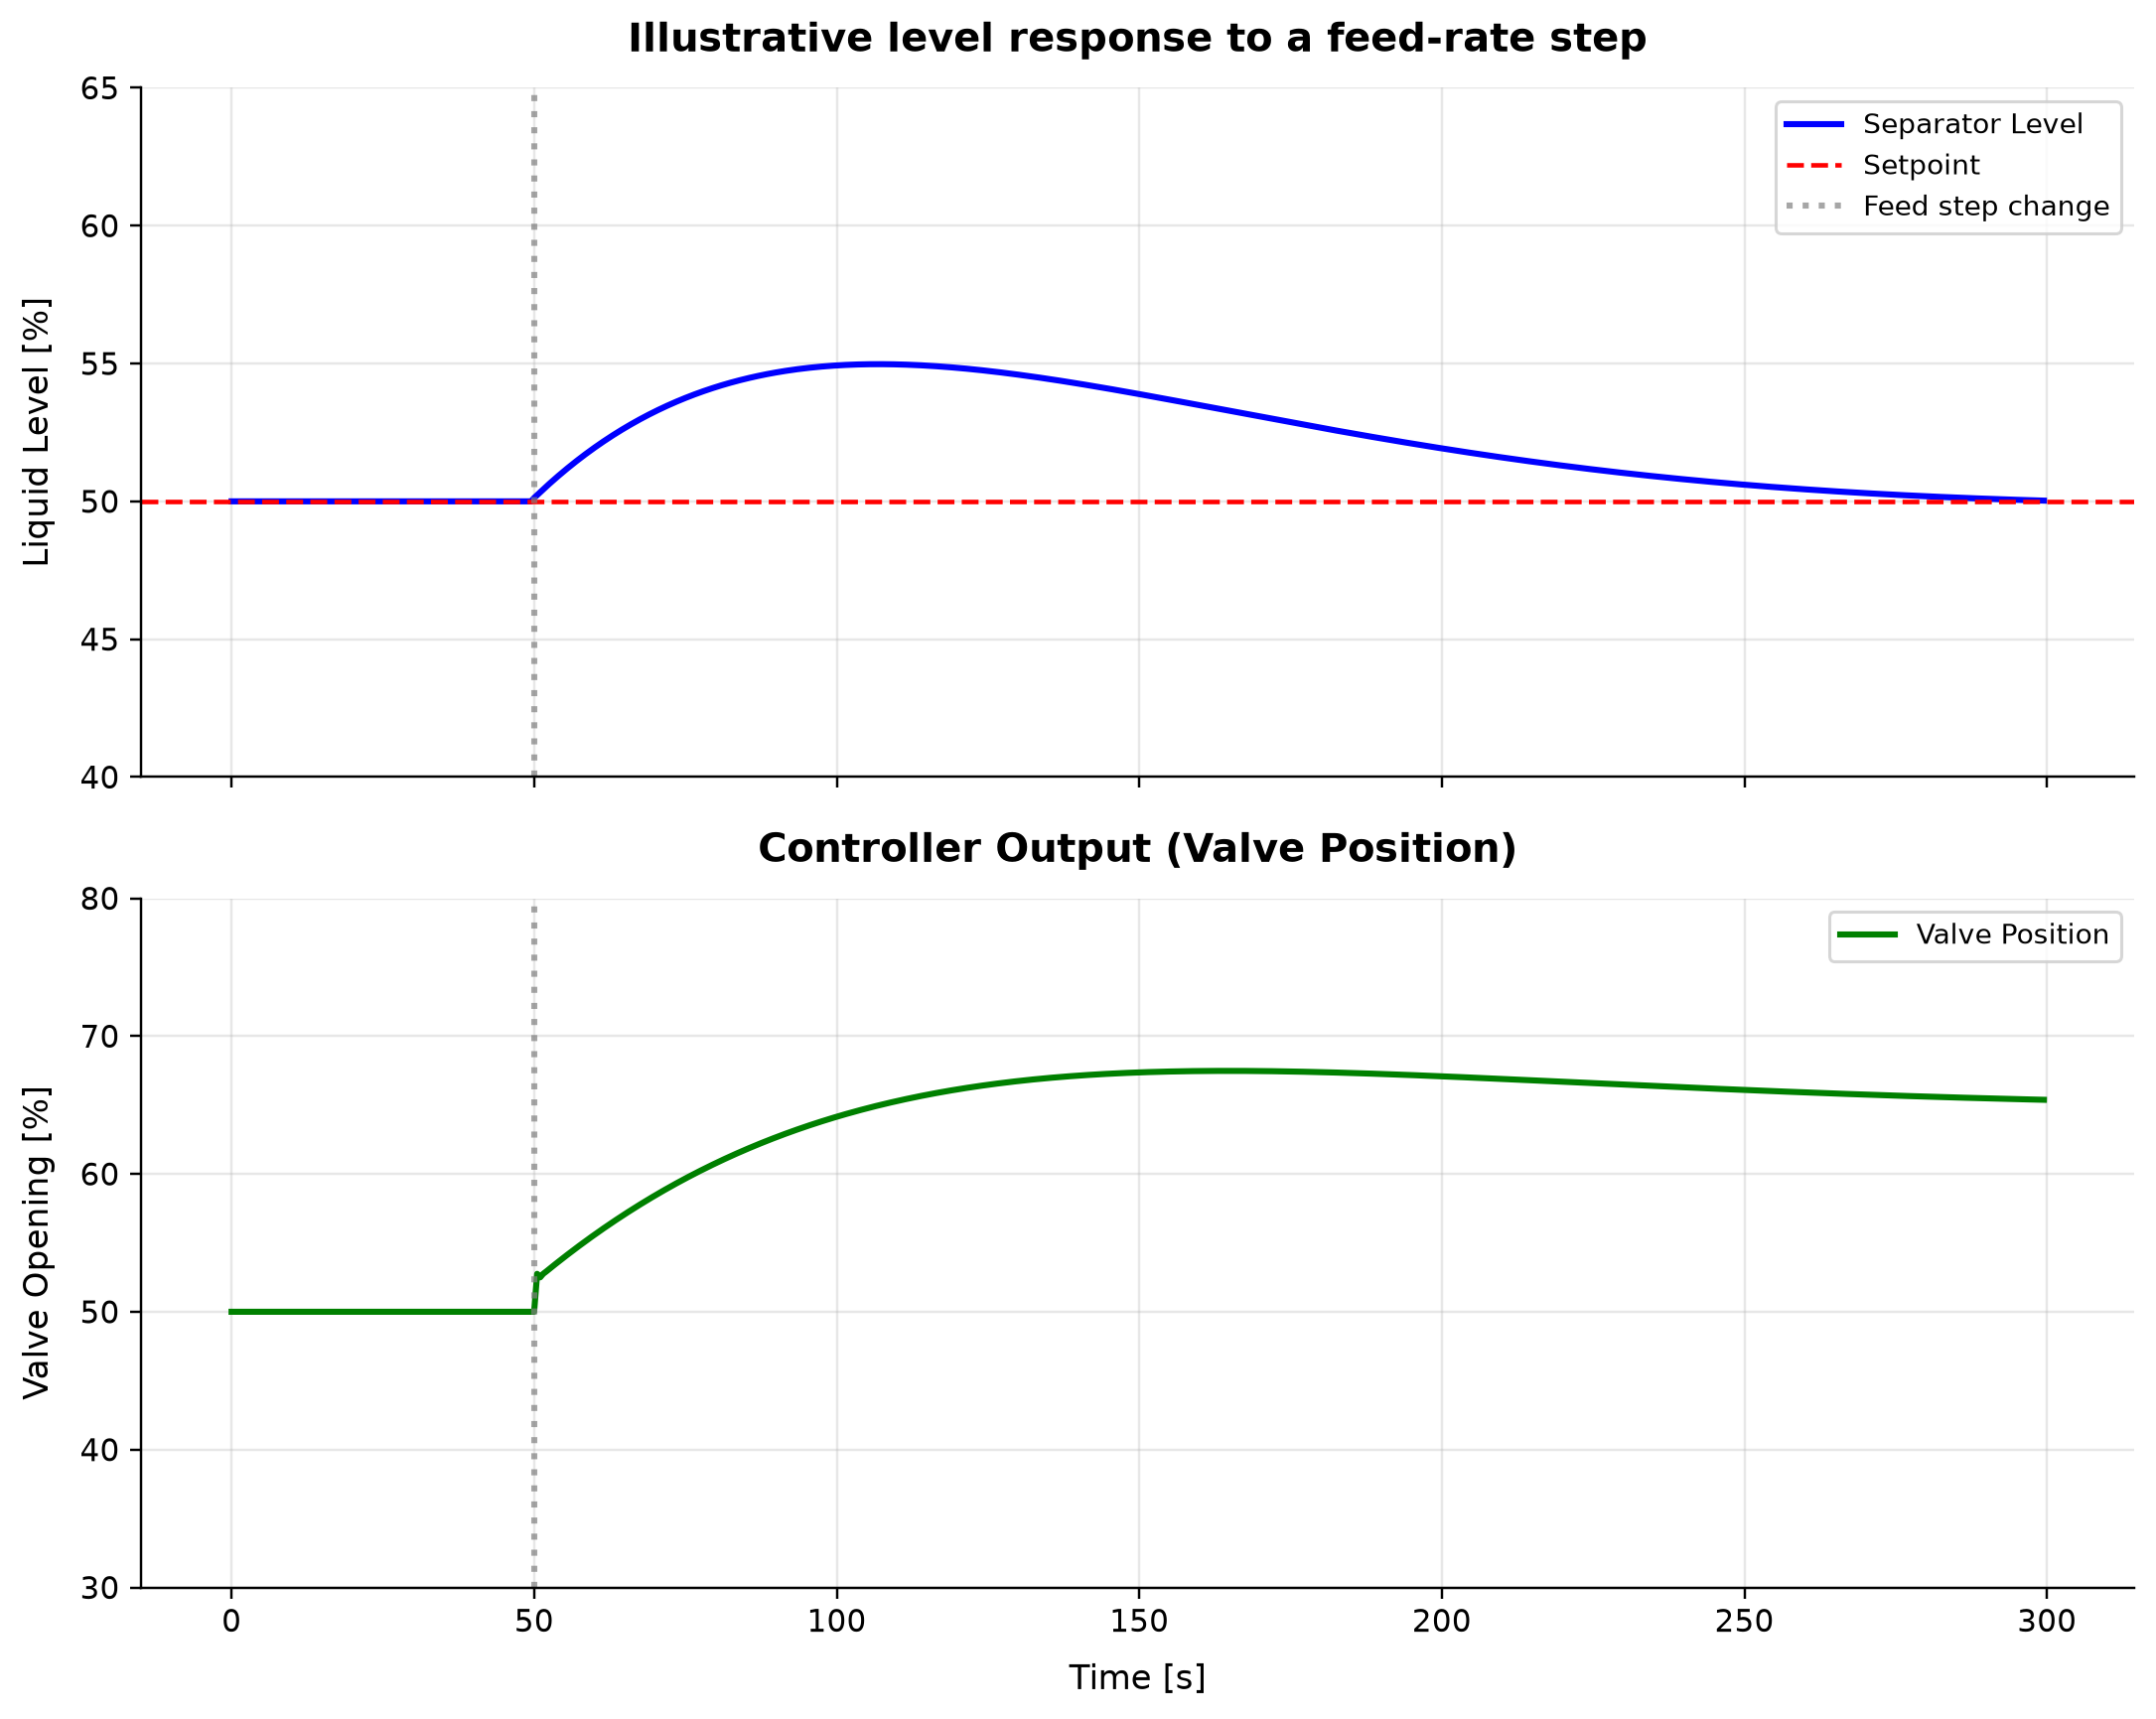

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Level response
ax1.plot(time, level * 100, 'b-', linewidth=2, label='Separator Level')
ax1.axhline(y=level_setpoint * 100, color='r', linestyle='--', linewidth=1.5, label='Setpoint')
ax1.axvline(x=50, color='gray', linestyle=':', alpha=0.7, label='Feed step change')
ax1.set_ylabel('Liquid Level [%]')
ax1.set_title('Illustrative level response to a feed-rate step')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(40, 65)

# Valve position
ax2.plot(time, valve_pos, 'g-', linewidth=2, label='Valve Position')
ax2.axvline(x=50, color='gray', linestyle=':', alpha=0.7)
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Valve Opening [%]')
ax2.set_title('Controller Output (Valve Position)')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(30, 80)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch20_level_controller_response.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved to ../figures/ch20_level_controller_response.png")

**Executed-figure discussion.** Separator Level: liquid level spans 50–54.98 % across the plotted cases. Valve Position: valve opening spans 50–67.48 % across the plotted cases.

In the illustrative Python inventory balance, a higher level commands a larger outlet opening, removing the excess inventory after the feed step. The trajectory explains controller action; it is not a NeqSim transient vessel validation. Use a validated vessel inventory and energy model before transferring controller gains to plant equipment.


## 29.5 Effect of PID Tuning Parameters

We compare different PID tuning settings to illustrate the effect of proportional
gain $K_p$ on the closed-loop response.

Figure saved to ../figures/ch20_pid_tuning_comparison.png


ch20_dynamic_simulation.ipynb:cell11:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


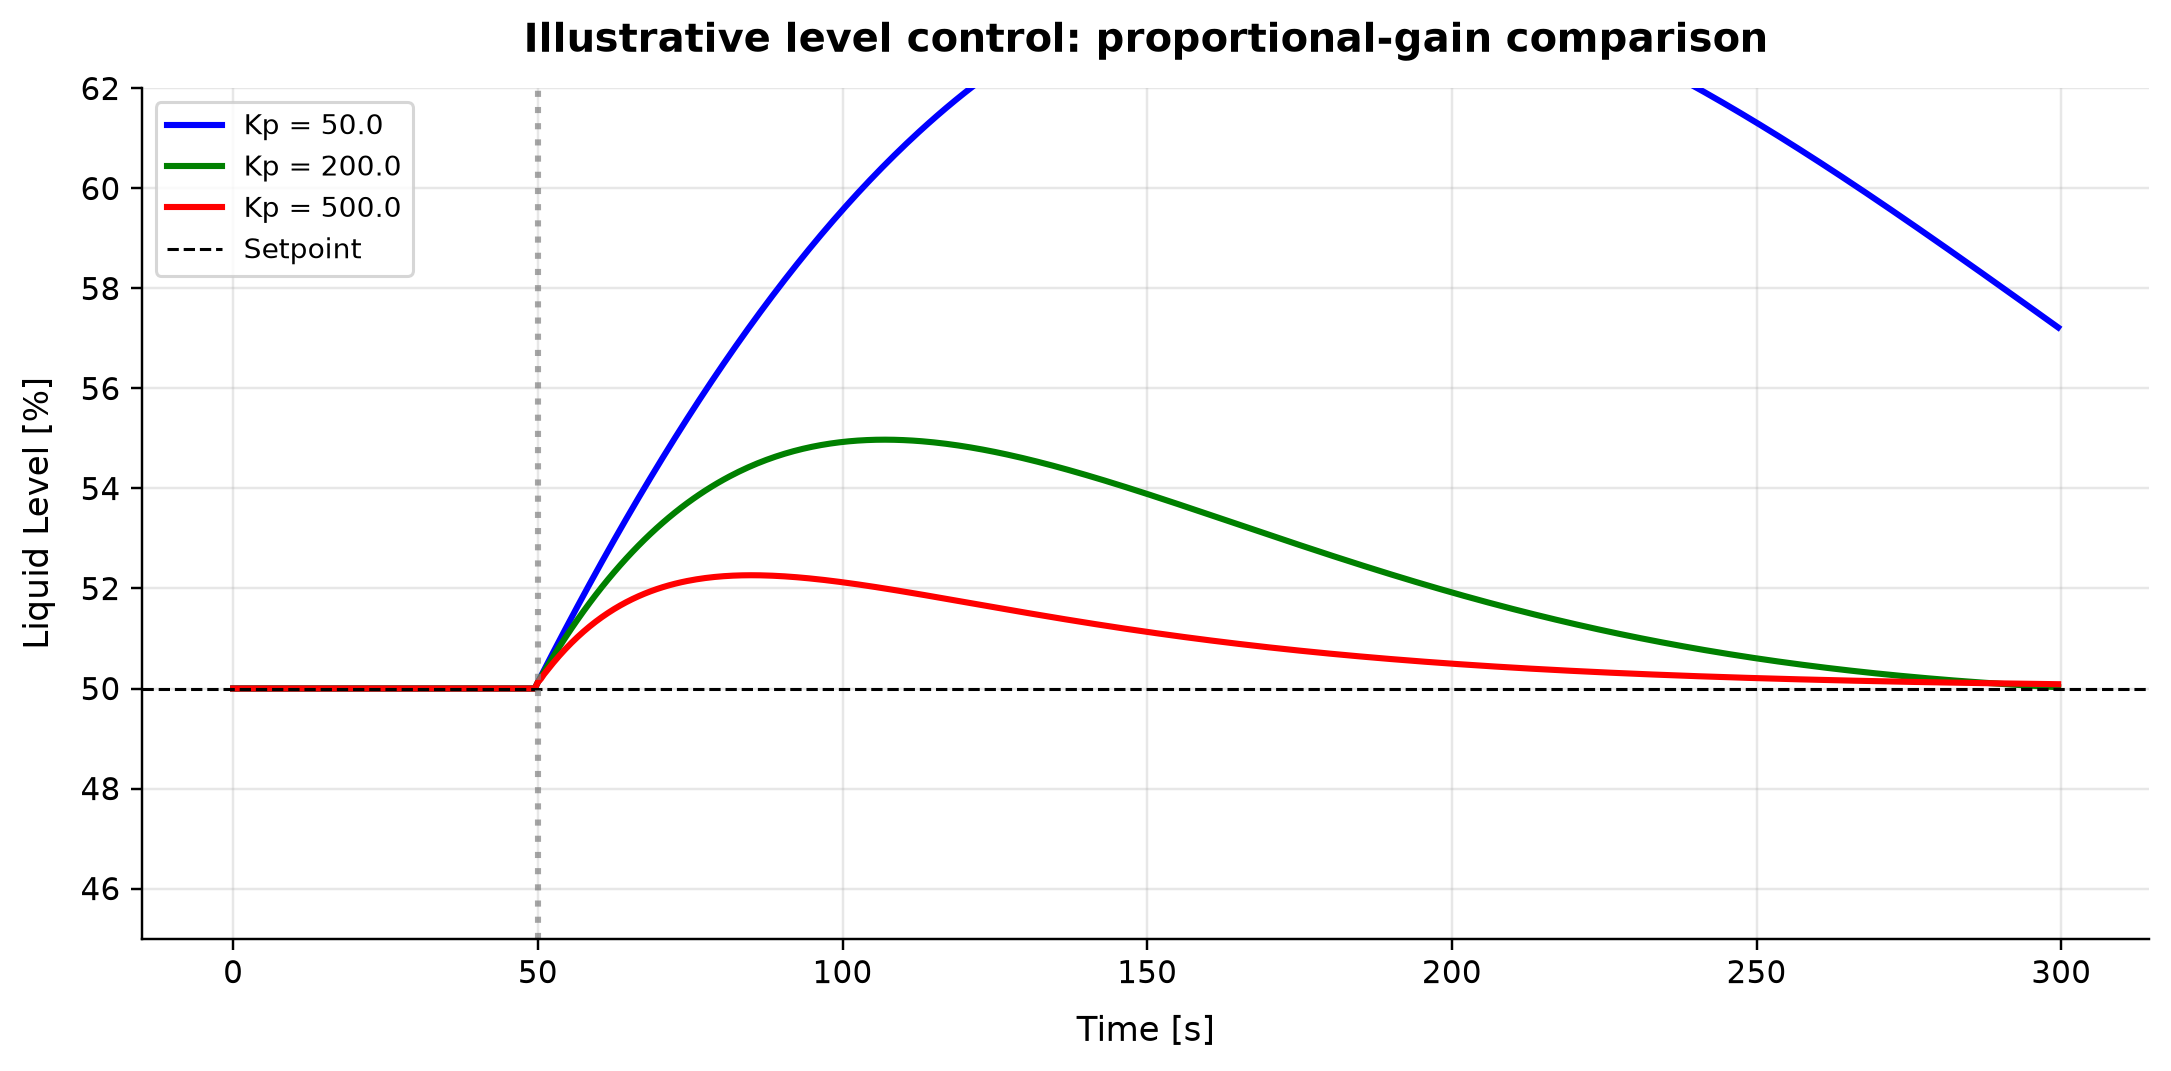

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

kp_values = [50.0, 200.0, 500.0]
colors = ['blue', 'green', 'red']

for kp_val, color in zip(kp_values, colors):
    lev = np.zeros(n)
    lev[0] = level_setpoint
    int_err = 0.0
    prev_err = 0.0
    vp = 50.0

    for i in range(1, n):
        err = lev[i-1] - level_setpoint
        int_err += err * dt
        deriv = (err - prev_err) / dt
        vp = 50.0 + kp_val * (err + int_err / Ti + Td * deriv)
        vp = np.clip(vp, 0, 100)
        d_lev = (-K_process * (vp - 50.0) / 100.0 + feed_disturbance[i]) / tau_process
        lev[i] = np.clip(lev[i-1] + d_lev * dt, 0, 1)
        prev_err = err

    ax.plot(time, lev * 100, color=color, linewidth=2, label=f'Kp = {kp_val}')

ax.axhline(y=level_setpoint * 100, color='black', linestyle='--', linewidth=1, label='Setpoint')
ax.axvline(x=50, color='gray', linestyle=':', alpha=0.7)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Liquid Level [%]')
ax.set_title('Illustrative level control: proportional-gain comparison')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(45, 62)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch20_pid_tuning_comparison.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved to ../figures/ch20_pid_tuning_comparison.png")

**Executed-figure discussion.** Kp = 50.0: liquid level spans 50–64.48 % across the plotted cases. Kp = 200.0: liquid level spans 50–54.98 % across the plotted cases.

Increasing the proportional gain makes the illustrative controller respond more strongly to a level error. The smaller excursion here is conditional on the simplified process response and absence of realistic actuator limits and noise. Repeat the tuning study with valve travel, measurement delay and plant dynamics before deployment.


## 29.6 Summary

**Key takeaways:**

1. **Dynamic simulation** reveals transient behaviour that steady-state models miss.
2. **PID controllers** are the workhorse of process control — proper tuning of $K_p$, $T_i$, $T_d$ is essential.
3. **Higher $K_p$** gives faster response but risks overshoot and oscillation.
4. **Integral action** ($T_i$) eliminates steady-state offset but can cause sluggish or oscillatory behavior if too aggressive.
5. NeqSim supports dynamic simulation via `runTransient()` with configurable controllers and measurement devices.

## Numerical output and figure provenance
The following table is extracted from the plotted numerical data. Each saved figure has an adjacent CSV and JSON record; missing points remain visible and are not replaced by interpolated results. Extrema summarize the sampled operating envelope, and are not independent validation of the model.


In [7]:
figure_results = export_figure_summary(NOTEBOOK_PATH)
print(figure_results.to_string(index=False, float_format=lambda value: f'{value:.6g}'))


                            Figure  Panel           Series     Output / unit  Minimum  Maximum  Finite points  Missing points
ch20_level_controller_response.png      1  Separator Level  Liquid Level [%]       50   54.976            600               0
ch20_level_controller_response.png      1         Setpoint  Liquid Level [%]       50       50              2               0
ch20_level_controller_response.png      1 Feed step change  Liquid Level [%]        0        1              2               0
ch20_level_controller_response.png      2   Valve Position Valve Opening [%]       50  67.4761            600               0
ch20_level_controller_response.png      2          Curve 2 Valve Opening [%]        0        1              2               0
    ch20_pid_tuning_comparison.png      1        Kp = 50.0  Liquid Level [%]       50  64.4767            600               0
    ch20_pid_tuning_comparison.png      1       Kp = 200.0  Liquid Level [%]       50   54.976            600         